In [17]:
import duckdb
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Check and change working directory

import os
os.chdir('..')
print(os.getcwd())

c:\Users\charl\OneDrive\Documents\Personal Projects\Ultra_Processed_Food\ultra-processed-food


In [7]:
# Check full schema

con = duckdb.connect()
schema = con.execute("DESCRIBE SELECT * FROM 'data/raw/food.parquet'").df()
print(schema.to_string())

                                column_name                                                                                                                                                                                                                                              column_type null   key default extra
0                               additives_n                                                                                                                                                                                                                                                  INTEGER  YES  None    None  None
1                            additives_tags                                                                                                                                                                                                                                                VARCHAR[]  YES  None    None  None
2                            allergens_tags   

In [9]:
df = con.execute(""" 
    SELECT code, product_name, nova_group, ingredients_text, 
                additives_n, additives_tags, categories_tags, countries_tags, 
                created_t, nutriments
    FROM 'data/raw/food.parquet'
    WHERE nova_group IS NOT NULL
""").df()

print(f"Labeled rows: {len(df):,}")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Labeled rows: 1,131,979


In [15]:
def is_missing(x):
    """Check if a value is missing, whether it's None, NaN, or an empty array/list."""
    if x is None:
        return True
    if isinstance(x, (list, tuple, np.ndarray, pd.Series)):
        return len(x) == 0
    try:
        return bool(pd.isna(x))
    except (TypeError, ValueError):
        return False

def extract_text(struct_list, preferred_lang = 'en'):
    """
    Function that pulls text out of a list of {lang, text} dictionaries. Preference is English but default to the first
    language available.
    """
    if is_missing(struct_list):
        return None
    for item in struct_list:
        if item['lang'] == preferred_lang:
            return item['text']
    return struct_list[0]['text']
    

def extract_nutrient(nutrient_list, name):
    """
    Pull the per-100g value for a named nutrient outr of the nutriments list
    """
    if is_missing(nutrient_list):
        return None
    for item in nutrient_list:
        if item['name'] == name:
            return item['100g']
    return None

df['product_name_text'] = df['product_name'].apply(extract_text)
df['ingredients_text_clean'] = df['ingredients_text'].apply(extract_text)

for nutrient_name, new_col in [
    ('energy-kcal', 'energy_kcal_100g'),
    ('sugars', 'sugars_100g'),
    ('fat', 'fat_100g'),
    ('saturated-fat', 'saturated_fat_100g'),
    ('sodium', 'sodium_100g'),
]:
    df[new_col] = df['nutriments'].apply(lambda x: extract_nutrient(x, nutrient_name))

df['created_datetime'] = pd.to_datetime(df['created_t'], unit='s')

In [19]:
# Check language coverage

df['ingredients_text_clean'].isna().mean()

np.float64(0.044317959962154777)

Roughly 4.4% lack English ingredient text. Defaulting to English won't cost too much data.

In [ ]:
# Check if 4.4% non-missing data is concentrated in a certain area

# Missing ingredients
df['missing_ingredients'] = df['ingredients_text_clean'].isna()
countries_exploded = df.explode('countries_tags')

missing_by_country = countries_exploded.groupby('countries_tags')['missing_ingredients'].agg(['mean', 'count'])
missing_by_country[missing_by_country['count'] > 100].sort_values('mean', ascending=False).head(15)

,mean,count
countries_tags,,
en:nigeria,0.241935,124
en:bangladesh,0.209524,105
en:cameroon,0.201754,114
en:spain,0.147108,52628
en:georgia,0.142361,288
en:iraq,0.142157,204
en:italy,0.140559,36362
en:puerto-rico,0.139623,265
en:united-arab-emirates,0.123547,688


Form of mild bias here. Nigeria, Bangladesh and Cameroon are 20-24% missing. Roughly 5x the average. These are, however, low volume countries, so not that many rows are actually affected. Spain and Italy have roughly 14-15% missing but much larger volumes, bit more connsequential. These aren't English speaking countries so this is natural missingness. Mild under-representation of products in non-English markets.

C:\Users\charl\AppData\Local\Temp\ipykernel_16052\779464977.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=counts.index.astype(int), y=counts.values, palette=purple_palette, ax=ax)
C:\Users\charl\AppData\Local\Temp\ipykernel_16052\779464977.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['1', '2', '3', '4'])


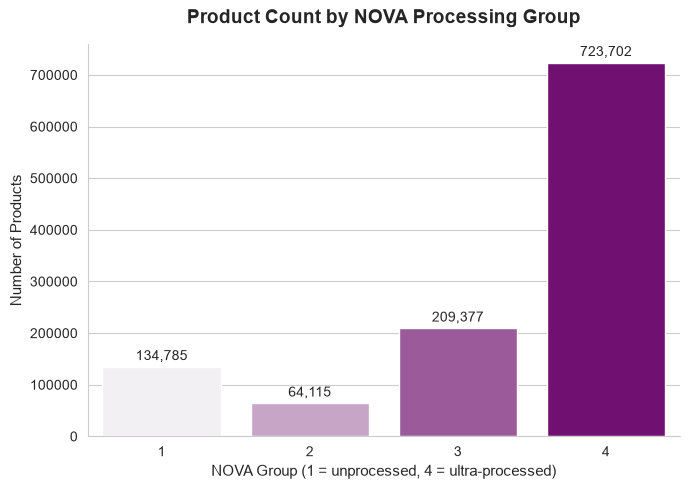

In [23]:
# Class balance

counts = df['nova_group'].value_counts().sort_index()

# Purple colour palette
purple_palette = sns.light_palette("purple", n_colors=len(counts), reverse=False)

fig, ax = plt.subplots(figsize=(7, 5))
bars = sns.barplot(x=counts.index.astype(int), y=counts.values, palette=purple_palette, ax=ax)

for bar in bars.patches:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + (counts.max() * 0.01), f'{int(height):,}', ha='center', va='bottom', fontsize=10)

ax.set_title('Product Count by NOVA Processing Group', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('NOVA Group (1 = unprocessed, 4 = ultra-processed)', fontsize=11)
ax.set_ylabel('Number of Products', fontsize=11)
ax.set_xticklabels(['1', '2', '3', '4'])

sns.despine()
plt.tight_layout()
plt.show()

Strong imbalance. Highly dominated by ultra-processed products

In [27]:
categories_exploded = df.explode('categories_tags')

top_category_balance = (categories_exploded.groupby('categories_tags')['nova_group'].value_counts(normalize=True).unstack().fillna(0))

# Filter to categories with more than 200 products
category_sizes = categories_exploded['categories_tags'].value_counts()
top_category_balance[category_sizes > 200]

C:\Users\charl\AppData\Local\Temp\ipykernel_16052\4162903222.py:7: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  top_category_balance[category_sizes > 200]


nova_group,1,2,3,4
categories_tags,,,,
af:fusilli,0.936877,0.000000,0.013289,0.049834
ca:cervesa-ipa,0.000000,0.000000,0.901370,0.098630
en:Dagligvarer,0.118644,0.000000,0.188136,0.693220
en:Groceries,0.089401,0.029493,0.296774,0.584332
en:Kaas,0.006780,0.000000,0.623729,0.369492
...,...,...,...,...
fr:saucisses-seches,0.000000,0.000000,0.033994,0.966006
fr:specialites-laitieres,0.043269,0.000000,0.026442,0.930288
fr:specialites-laitieres-aux-fruits,0.000000,0.000000,0.004808,0.995192


Labels like 'Groceries' which are generic/broad terms may lack signal.

In [35]:
# Check the maximum proportion in any NOVA group

category_sizes = categories_exploded['categories_tags'].value_counts()
filtered_balance = top_category_balance[category_sizes > 200].copy()

filtered_balance['max_concentration'] = filtered_balance.max(axis=1)

# Least distinctive (most evenly spread across NOVA groups)
print(filtered_balance.sort_values('max_concentration').head(10))

nova_group                             1         2         3         4  \
categories_tags                                                          
en:peanut-butters               0.268071  0.084272  0.319288  0.328369   
en:legume-butters               0.267509  0.084116  0.319495  0.328881   
fr:autres-produits              0.311971  0.070133  0.285369  0.332527   
en:seaweeds-and-their-products  0.332673  0.003960  0.320792  0.342574   
en:nuts-and-their-products      0.342832  0.060719  0.292475  0.303974   
en:lean-fishes                  0.278422  0.017401  0.344548  0.359629   
en:nut-butters                  0.359749  0.093762  0.286387  0.260102   
en:cabbages                     0.366102  0.000000  0.349153  0.284746   
en:strawberry-applesauces       0.369458  0.000000  0.344828  0.285714   
en:oilseed-purees               0.370075  0.084289  0.284539  0.261097   

nova_group                      max_concentration  
categories_tags                                    
en:pean

C:\Users\charl\AppData\Local\Temp\ipykernel_16052\3238427883.py:4: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  filtered_balance = top_category_balance[category_sizes > 200].copy()


Peanut butters, nut butters, seaweed products, etc. Can all vary quite a lot depending on what has been added to them so makes sense.

In [34]:
# Most distinctive (most concentrated in one NOVA group)
print(filtered_balance.sort_values('max_concentration', ascending=False).head(10))

nova_group                               1    2    3    4  max_concentration
categories_tags                                                             
en:citrus-honeys                       0.0  1.0  0.0  0.0                1.0
en:ice-cream-log                       0.0  0.0  0.0  1.0                1.0
en:rosemary-honeys                     0.0  1.0  0.0  0.0                1.0
en:forest-honeys                       0.0  1.0  0.0  0.0                1.0
en:pine-nuts                           1.0  0.0  0.0  0.0                1.0
en:yule-log                            0.0  0.0  0.0  1.0                1.0
en:orange-blossom-honeys               0.0  1.0  0.0  0.0                1.0
en:olive-oils-from-italy               0.0  1.0  0.0  0.0                1.0
en:marble-cakes                        0.0  0.0  0.0  1.0                1.0
en:marshmallows-coated-with-chocolate  0.0  0.0  0.0  1.0                1.0


Honeys are almost perfectly consistent as group 2. Makes sense given honey is slightly processed. Things that are obviously UPF also fall into this category like marble cakes or mashmallows coated with chocolate. So, category is a strong signal for some food types (honeys, desserts, whole foods) but a weak one for others (spreads, butters, some proteins) where ingredients can vary.